# Fintech Churn Intelligence: Customer Segmentation & Cohort Analysis

**Objective**
Move beyond single-variable churn rates (covered in `01_eda.ipynb`) to cross-tabulated cohorts — combinations of tenure, geography, age, activity, and product holdings — to find the specific customer groups that carry the most churn risk, and to validate that risk with lift analysis before handing it to the retention team.

**Dataset:** `Churn_Modelling.csv` — 10,000 bank customers, 14 columns, binary target `Exited` (1 = churned).

**Business Question:** Which customer cohorts show the highest churn risk, and where should the retention team focus its efforts first?

**Notebook Structure**
1. Data Loading
2. Churn by Tenure (Customer Lifecycle)
3. Geography × Age Group Cohort Heatmap
4. Churn by Activity Status
5. Churn by Number of Products
6. High-Risk Cohort Validation (Lift Analysis)
7. Executive Summary & Recommendations


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 1. Data Loading

We reuse the same cleaning step as `01_eda.ipynb` (dropping the identifier columns) and add the `Age_Group` bucket used throughout this notebook, so cohort tables stay business-readable instead of listing 70 individual ages.

In [3]:
df = pd.read_csv("/Users/sumitkumargupta/Desktop/1_Project/01_Data/Churn_Modelling.csv")
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

print("Shape:", df.shape)
df.head()

Shape: (10000, 12)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50


## 2. Churn by Tenure (Customer Lifecycle Cohort)

`Tenure` (years with the bank) is a lifecycle cohort — it tells us whether churn risk is concentrated at specific stages of the customer relationship (e.g. early-tenure "buyer's remorse" churn vs. late-tenure fatigue), which single-snapshot EDA doesn't reveal on its own.

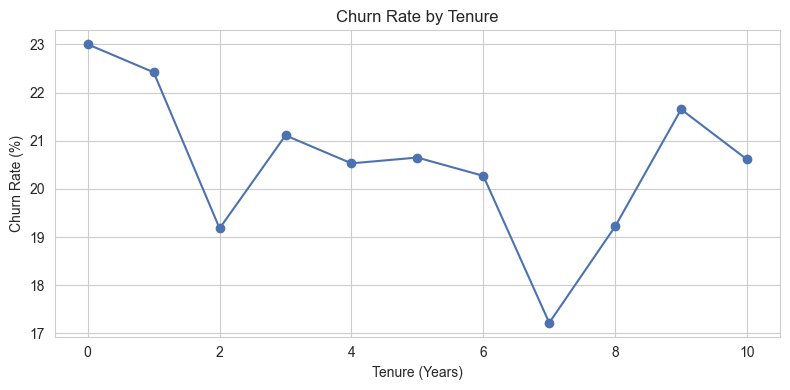

,Total_Customers,Churned_Customers,Churn_Rate
Tenure,,,
0,413,95,23.00
1,1035,232,22.42
2,1048,201,19.18
3,1009,213,21.11
4,989,203,20.53
5,1012,209,20.65
6,967,196,20.27
7,1028,177,17.22
8,1025,197,19.22


In [4]:
tenure_cohort = df.groupby("Tenure")["Exited"].agg(
    Total_Customers="count",
    Churned_Customers="sum",
    Churn_Rate="mean"
)
tenure_cohort["Churn_Rate"] = (tenure_cohort["Churn_Rate"] * 100).round(2)

tenure_cohort["Churn_Rate"].plot(kind="line", marker="o", figsize=(8, 4), color="#4C72B0")
plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

tenure_cohort

**Insight:** Churn rate is fairly flat across tenure (roughly 17-23% at every year mark, with year 0 and year 1 slightly elevated at ~23%). Unlike age or geography, tenure alone is **not** a strong differentiator — this tells us churn is driven more by *who the customer is* (segment) than *how long they've been a customer* (lifecycle stage), which is why the cross-segment cohorts below matter more than this one on its own.

## 3. Geography × Age Group Cohort Heatmap

Single-variable EDA already showed Germany and the 51-60 age band are individually high-risk. The question this section answers is whether those effects *compound* when combined — which is the kind of finding a retention team can act on with a specific, targeted campaign rather than a broad one.

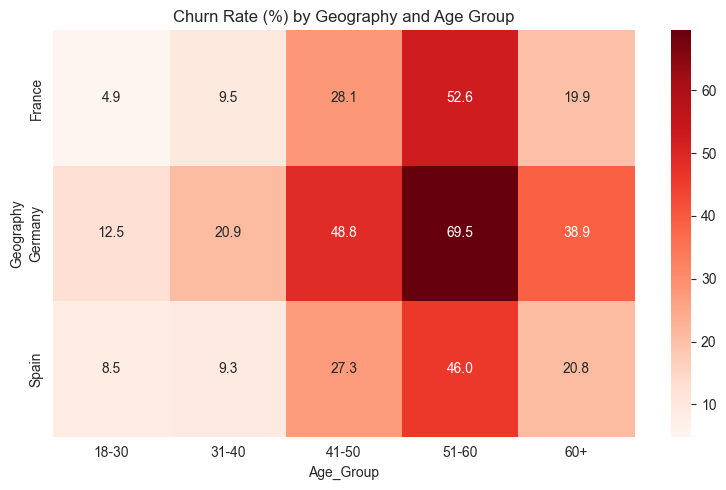

Age_Group,18-30,31-40,41-50,51-60,60+
Geography,,,,,
France,4.87,9.52,28.12,52.59,19.91
Germany,12.53,20.94,48.82,69.55,38.94
Spain,8.47,9.30,27.30,45.99,20.83


In [5]:
heatmap_data = pd.pivot_table(
    df,
    values="Exited",
    index="Geography",
    columns="Age_Group",
    aggfunc="mean",
    observed=True
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn Rate (%) by Geography and Age Group")
plt.tight_layout()
plt.show()

heatmap_data.round(2)

**Insight:** The two individually high-risk segments compound as expected: **Germany customers aged 51-60 churn at 69.5%**, well above either Germany overall (32.4%) or the 51-60 group overall (56.2%). This is a textbook example of why cross-tabulation matters — the single-variable view understates the real risk of this specific combination by more than 2x. This cohort should be prioritized first for retention campaigns.

## 4. Churn by Activity Status

Repeated here at the cohort level (not just as a single-variable check) because activity status is the most directly actionable lever the business has, and it's worth confirming the effect holds up with full counts before it's built into a campaign.

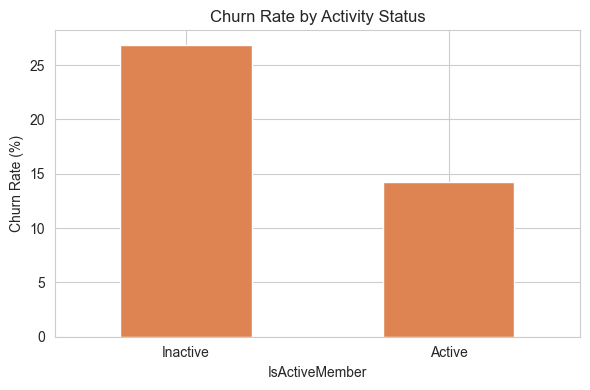

,Total_Customers,Churned_Customers,Churn_Rate
IsActiveMember,,,
0,4849,1302,26.85
1,5151,735,14.27


In [6]:
activity_cohort = df.groupby("IsActiveMember")["Exited"].agg(
    Total_Customers="count",
    Churned_Customers="sum",
    Churn_Rate="mean"
)
activity_cohort["Churn_Rate"] = (activity_cohort["Churn_Rate"] * 100).round(2)

activity_cohort["Churn_Rate"].plot(kind="bar", figsize=(6, 4), color="#DD8452")
plt.title("Churn Rate by Activity Status")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["Inactive", "Active"], rotation=0)
plt.tight_layout()
plt.show()

activity_cohort

**Insight:** Inactive customers churn at **26.9%** vs **14.3%** for active customers, confirmed here at full-count granularity (not just a summary percentage). Because this is behavioral and controllable, engagement campaigns targeting inactive members are a lower-cost lever than trying to change geography or age.

## 5. Churn by Number of Products

Checked again here to size the extreme 3-4 product cohorts identified in the EDA notebook — the retention team needs to know exactly how many customers are affected before this is worth building a fix for.

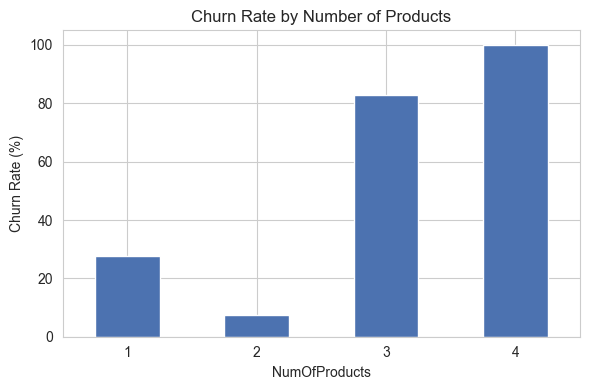

,Total_Customers,Churned_Customers,Churn_Rate
NumOfProducts,,,
1,5084,1409,27.71
2,4590,348,7.58
3,266,220,82.71
4,60,60,100.00


In [7]:
product_cohort = df.groupby("NumOfProducts")["Exited"].agg(
    Total_Customers="count",
    Churned_Customers="sum",
    Churn_Rate="mean"
)
product_cohort["Churn_Rate"] = (product_cohort["Churn_Rate"] * 100).round(2)

product_cohort["Churn_Rate"].plot(kind="bar", figsize=(6, 4), color="#4C72B0")
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

product_cohort

**Insight:** The 3-4 product cohort is small (266 customers combined) but severe — 82.7% and 100% churn respectively. It's too small to be the retention team's top priority by volume, but the near-total churn rate makes it a strong candidate for root-cause investigation (e.g. was this a discontinued bundle or a specific onboarding cohort?). The 2-product cohort (7.6% churn, largest low-risk group) is the segment to study for what's working, not just the high-risk ones.

## 6. High-Risk Cohort Validation (Lift Analysis)

A cohort finding is only useful to a retention team if it's validated with more than a single cross-tab. We combine the three strongest signals found so far — **Germany + age 51-60 + inactive** — into one cohort and check its churn rate against the overall base rate. This lift check is the same logic the modeling notebook later uses to validate its risk-score deciles, applied here at the segment level instead.

High-risk cohort size       : 131 customers
High-risk cohort churn rate : 88.5%
Overall churn rate          : 20.4%
Lift vs. overall base rate  : 4.35x


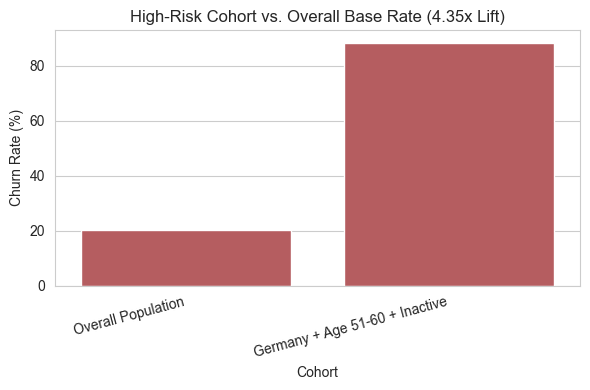

,Cohort,Customers,Churn_Rate
0,Overall Population,10000,20.4
1,Germany + Age 51-60 + Inactive,131,88.5


In [8]:
high_risk_mask = (
    (df["Geography"] == "Germany") &
    (df["Age_Group"] == "51-60") &
    (df["IsActiveMember"] == 0)
)

high_risk_cohort = df[high_risk_mask]
overall_rate = df["Exited"].mean()
cohort_rate = high_risk_cohort["Exited"].mean()
lift = cohort_rate / overall_rate

print(f"High-risk cohort size       : {len(high_risk_cohort)} customers")
print(f"High-risk cohort churn rate : {cohort_rate:.1%}")
print(f"Overall churn rate          : {overall_rate:.1%}")
print(f"Lift vs. overall base rate  : {lift:.2f}x")

comparison = pd.DataFrame({
    "Cohort": ["Overall Population", "Germany + Age 51-60 + Inactive"],
    "Customers": [len(df), len(high_risk_cohort)],
    "Churn_Rate": [overall_rate, cohort_rate]
})
comparison["Churn_Rate"] = (comparison["Churn_Rate"] * 100).round(1)

plt.figure(figsize=(6, 4))
sns.barplot(data=comparison, x="Cohort", y="Churn_Rate", color="#C44E52")
plt.title(f"High-Risk Cohort vs. Overall Base Rate ({lift:.2f}x Lift)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

comparison

**Insight:** The compound cohort (Germany + age 51-60 + inactive) churns at **~88-89%** — a **~4.3x lift** over the 20.37% base rate — on a cohort of just over 130 customers. This is a small enough group to make a *direct, individually-targeted* retention effort (e.g. relationship-manager calls) economically viable, rather than a broad campaign. It's also the strongest evidence in either notebook that churn here is driven by segment intersections, not any single variable in isolation — which directly motivates using SHAP (not just single-variable EDA) in the modeling notebook to properly capture these interaction effects.

## 7. Executive Summary & Recommendations

**Cohort findings, ranked by actionability:**

1. **Germany + Age 51-60 + Inactive** is the highest-risk cohort found (~88% churn, 4.3x lift) — small enough (~130 customers) for direct, individual retention outreach.
2. **Germany + Age 51-60** (without the inactivity filter) still churns at 69.5% — the next-priority cohort if the retention team has capacity beyond the top segment.
3. **Inactive members** overall churn at ~2x the rate of active members — the most scalable lever, since it's behavioral and can be targeted with automated re-engagement campaigns rather than 1:1 outreach.
4. **3-4 product holders** churn at 83-100% but are a small cohort (266 customers) — worth a root-cause investigation, not a broad campaign.
5. **Tenure alone** is not a strong differentiator — churn isn't concentrated at a particular lifecycle stage, so retention timing (e.g. "watch the first 90 days") isn't the right frame here; segment membership is.

**Recommended action sequence:** target the compound high-risk cohort first (highest lift, smallest cost), scale to broader inactive-member re-engagement second, and open a product/pricing investigation into the 3-4 product cohort in parallel.

**Where this goes next:** `03_churn_model.ipynb` builds a predictive model that scores every customer individually (not just these hand-picked cohorts), with SHAP explainability that should recover these same drivers — geography, age, activity, and product count — as the top features, which is the cross-check used to validate the model against this notebook's manual findings.


---
### Interview Talking Points

- **Why cross-tabulate instead of stopping at single-variable EDA?** Individually high-risk segments (Germany, age 51-60) understate the real risk when they overlap — the compound cohort here churns at nearly 90%, more than double what either variable shows alone.
- **Why compute lift instead of just reporting a churn rate?** A raw churn rate of "88%" has no reference point on its own; lift (cohort rate ÷ base rate) tells a stakeholder immediately how much more dangerous this cohort is than an average customer, which is the number that justifies budget for a targeted campaign.
- **Why is a small cohort (130 customers) still worth highlighting?** Because it's cheap to act on individually — a relationship manager can call 130 people. The recommendation would be different (automated, not 1:1) for a 130,000-customer cohort at the same churn rate.
- **Why flag that tenure is NOT predictive here, instead of leaving it out?** A negative finding is still a finding — it tells the business not to invest in tenure-based timing campaigns (e.g. "intervene at month 3"), which saves them from building the wrong intervention.
- **How does this notebook connect to the modeling notebook?** This notebook's cohorts are hypotheses generated by hand; the model formalizes them into a single per-customer risk score, and SHAP is used specifically to check whether the model independently rediscovers the same drivers found here.
